In [1]:
import numpy as np
import pandas as pd
import math

In [2]:
'''
“Linear Regression from Scratch” - Purpose: the first project where you
build the algorithm, not just the pipeline around it — this is what makes gradient
descent click permanently instead of staying an abstract diagram. - Spec:
numpy only, no scikit-learn. Generate or download a small single-feature or
two-feature dataset (e.g., a simple synthetic linear relationship with noise, or a
small real dataset like height-vs-weight). - Deliverables: implement the cost
function (MSE), the gradient computation, and the update loop by hand; plot
the cost decreasing over iterations to confirm convergence; plot your fitted line
against the data; compare your learned coefficients against np.linalg.lstsq
or scikit-learn’s LinearRegression on the same data and report how close they
are. - Stretch goal: implement logistic regression from scratch the same way
(sigmoid + binary cross-entropy loss instead of MSE) on a small 2-class synthetic
dataset — this directly previews Project 1’s core model family.
'''

'\n“Linear Regression from Scratch” - Purpose: the first project where you\nbuild the algorithm, not just the pipeline around it — this is what makes gradient\ndescent click permanently instead of staying an abstract diagram. - Spec:\nnumpy only, no scikit-learn. Generate or download a small single-feature or\ntwo-feature dataset (e.g., a simple synthetic linear relationship with noise, or a\nsmall real dataset like height-vs-weight). - Deliverables: implement the cost\nfunction (MSE), the gradient computation, and the update loop by hand; plot\nthe cost decreasing over iterations to confirm convergence; plot your fitted line\nagainst the data; compare your learned coefficients against np.linalg.lstsq\nor scikit-learn’s LinearRegression on the same data and report how close they\nare. - Stretch goal: implement logistic regression from scratch the same way\n(sigmoid + binary cross-entropy loss instead of MSE) on a small 2-class synthetic\ndataset — this directly previews Project 1’s cor

In [2]:
df = pd.read_csv('SOCR-HeightWeight.csv')
df.head()

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


In [3]:
x_array = df['Height(Inches)'].to_numpy()
x_array

array([65.78331, 71.51521, 69.39874, 68.2166 , 67.78781, 68.69784,
       69.80204, 70.01472, 67.90265, 66.78236, 66.48769, 67.62333,
       68.30248, 67.11656, 68.27967, 71.0916 , 66.461  , 68.64927,
       71.23033, 67.13118, 67.83379, 68.87881, 63.48115, 68.42187,
       67.62804, 67.20864, 70.84235, 67.49434, 66.53401, 65.44098,
       69.5233 , 65.8132 , 67.8163 , 70.59505, 71.80484, 69.20613,
       66.80368, 67.65893, 67.80701, 64.04535, 68.57463, 65.18357,
       69.65814, 67.96731, 65.98088, 68.67249, 66.88088, 67.69868,
       69.82117, 69.08817])

In [4]:
y_array = df['Weight(Pounds)'].to_numpy()
y_array

array([112.9925 , 136.4873 , 153.0269 , 142.3354 , 144.2971 , 123.3024 ,
       141.4947 , 136.4623 , 112.3723 , 120.6672 , 127.4516 , 114.143  ,
       125.6107 , 122.4618 , 116.0866 , 139.9975 , 129.5023 , 142.9733 ,
       137.9025 , 124.0449 , 141.2807 , 143.5392 ,  97.90191, 129.5027 ,
       141.8501 , 129.7244 , 142.4235 , 131.5502 , 108.3324 , 113.8922 ,
       103.3016 , 120.7536 , 125.7886 , 136.2225 , 140.1015 , 128.7487 ,
       141.7994 , 121.2319 , 131.3478 , 106.7115 , 124.3598 , 124.8591 ,
       139.6711 , 137.3696 , 106.4499 , 128.7639 , 145.6837 , 116.819  ,
       143.6215 , 134.9325 ])

In [5]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb - y[i]) ** 2
        cost_sum = cost_sum + cost
    total_cost = (1/(2*m)) * cost_sum
    return total_cost

In [6]:
compute_cost(x_array, y_array, 0.0, 0.0)

np.float64(8381.646705462179)

In [7]:
def z_score_normalization(x):
    mu = np.mean(x)
    sigma = np.std(x)
    x_norm = (x-mu)/sigma

    return x_norm


In [8]:
x_scaled = z_score_normalization(x_array)
x_scaled

array([-1.25697409,  1.91773552,  0.74549287,  0.09074466, -0.14674792,
        0.35728756,  0.96886738,  1.08666379, -0.08314184, -0.70363338,
       -0.86684133, -0.23784794,  0.13831075, -0.51853107,  0.12567705,
        1.68311196, -0.88162404,  0.33038625,  1.75994992, -0.51043353,
       -0.12128112,  0.45752086, -2.53206428,  0.20443692, -0.23523923,
       -0.467531  ,  1.54506064, -0.30929123, -0.84118622, -1.44657934,
        0.81448253, -1.24041901, -0.13096825,  1.40808936,  2.07815198,
        0.63881256, -0.69182494, -0.21813028, -0.13611367, -2.21957259,
        0.28904563, -1.58915022,  0.88916594, -0.04732881, -1.14754661,
        0.34324704, -0.64906641, -0.19611407,  0.97946285,  0.57347843])

In [9]:
compute_cost(x_scaled, y_array, 0.0, 0.0)

np.float64(8381.646705462179)

In [10]:
def compute_gradient(x, y, w, b): 
  
    m = x.shape[0]    
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        dj_db += dj_db_i
        dj_dw += dj_dw_i 
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

In [11]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    j_history = []
    p_history = []
    b = b_in
    w = w_in       

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w , b)     
        b = b - alpha * dj_db 
        w = w - alpha * dj_dw

        if i < 100000:
            j_history.append(cost_function(x,y,w,b))
            p_history.append([w,b])
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {j_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")

    return w, b, j_history, p_history

In [12]:
w_init = 0
b_init = 0

iterations = 100000
tmp_alpha = 0.01

w_final, b_final, j_hist, p_hist = gradient_descent(x_scaled, y_array, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 8.22e+03  dj_dw: -7.558e+00, dj_db: -1.288e+02   w:  7.558e-02, b: 1.28843e+00
Iteration 10000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.28843e+02
Iteration 20000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.28843e+02
Iteration 30000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.28843e+02
Iteration 40000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.28843e+02
Iteration 50000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.28843e+02
Iteration 60000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.28843e+02
Iteration 70000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.28843e+02
Iteration 80000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.28843e+02
Iteration 90000: Cost 5.28e+01  dj_dw: -4.351e-14, dj_db: -1.413e-12   w:  7.558e+00, b: 1.2

Text(0.5, 0, 'iteration step')

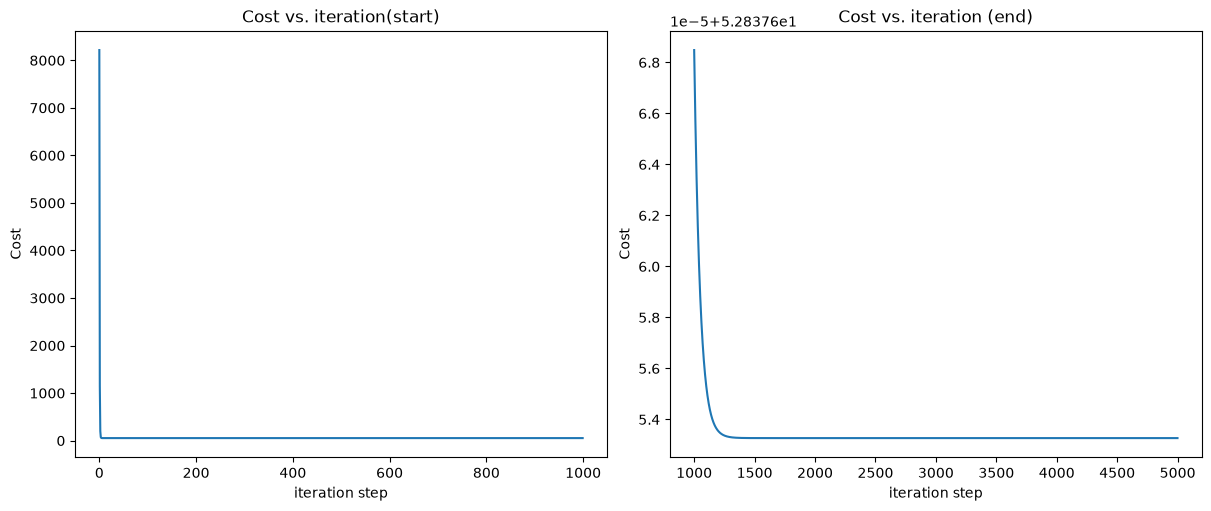

In [13]:
import matplotlib.pyplot as plt
plt.close('all')

fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,5))
ax1.plot(j_hist[::100])
ax2.plot(1000 + np.arange(len(j_hist[1000:5000])), j_hist[1000:5000])
ax1.set_title("Cost vs. iteration(start)"); ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')    

In [19]:
def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb


In [15]:
w = 7.5575
b = 128.8429

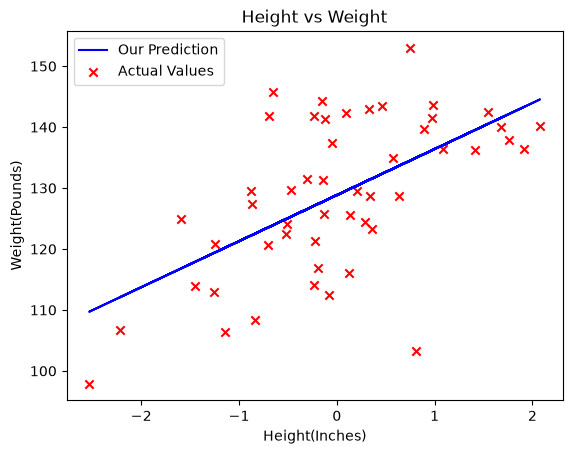

In [21]:
tmp_fwb = compute_model_output(x_scaled, w, b)
plt.plot(x_scaled, tmp_fwb, c='b',label='Our Prediction')
plt.scatter(x_scaled, y_array, marker='x', c='r',label='Actual Values')
plt.title("Height vs Weight")
plt.ylabel('Weight(Pounds)')
plt.xlabel('Height(Inches)')
plt.legend()

In [17]:
print("x_scaled shape:", x_scaled.shape)
print("tmp_fwb shape:", tmp_fwb.shape)
print("y_array shape:", y_array.shape)

x_scaled shape: (50,)
tmp_fwb shape: ()
y_array shape: (50,)


In [20]:
tmp_fwb = compute_model_output(x_scaled, w, b)
print("tmp_fwb shape:", tmp_fwb.shape)  # Should now print: (50,)

tmp_fwb shape: (50,)


In [23]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(x_scaled.reshape(-1, 1), y_array) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.56]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,128.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[7.07]


In [26]:
b = linear_model.intercept_
w = linear_model.coef_[0]
print(f"w = {w:}, b = {b:0.2f}")

w = 7.55750592108402, b = 128.84


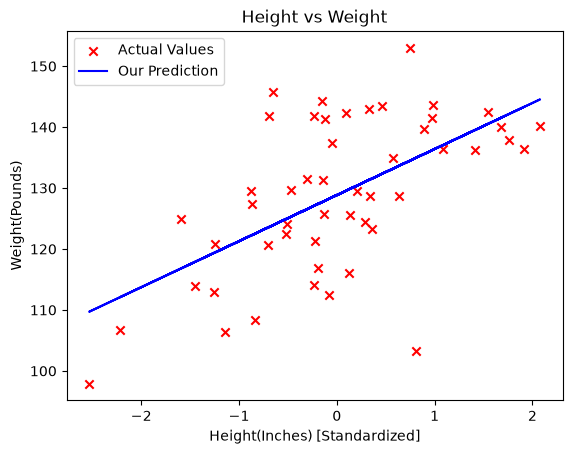

In [27]:
tmp_fwb = compute_model_output(x_scaled, w, b)

plt.scatter(x_scaled, y_array, marker='x', c='r', label='Actual Values')
plt.plot(x_scaled, tmp_fwb, c='b', label='Our Prediction')

plt.title("Height vs Weight")
plt.ylabel('Weight(Pounds)')
plt.xlabel('Height(Inches) [Standardized]')
plt.legend()
plt.show()